In [ ]:
from galpy.df import eddingtondf
from galpy.potential import NFWPotential, PlummerPotential, HernquistPotential
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from ezfalcon.simulation import Sim

In [ ]:
hostpot = NFWPotential(mvir=4, conc=10)
hostpot.turn_physical_on()

In [ ]:
dmpot = HernquistPotential(amp=1e10 * u.Msun, a=2*u.kpc)#NFWPotential(amp=1e10 * u.Msun, a=2*u.kpc)
dmpot.turn_physical_on()
stellarpot = PlummerPotential(amp=1e9 * u.Msun, b=0.5*u.kpc)
stellarpot.turn_physical_on()

In [ ]:
#rcutoff = hostpot.rtide(np.linalg.norm(prog_center_pos[:2]), z=prog_center_pos[2],  M = dmpot.mass(np.inf)*u.Msun)
mdm = dmpot.mass(np.inf)
mstar = stellarpot.mass(np.inf)#rcutoff)
print(f"Satellite mass within tidal radius: {mdm:.2e} Msun (DM), {mstar:.2e} Msun (stars)")
#print(rcutoff)

Satellite mass within tidal radius: 5.00e+09 Msun (DM), 1.00e+09 Msun (stars)


In [ ]:
ntotal = 10_000
frac = 2 # fraction of dm particle mass to stellar particle mass (2 * mstar = mdm)

ndm = int(mdm / (mdm + mstar) * ntotal / frac)
nstar = ntotal - ndm
print(f"Number of DM particles: {ndm}")
print(f"Number of stellar particles: {nstar}")

total_mass = mdm + mstar
print(f"\nTotal mass: {total_mass:.2e} Msun")
mdm_pt = mdm / ndm 
mstar_pt = mstar / nstar
print(f"DM particle mass: {mdm_pt:.2f} Msun")
print(f"Stellar particle mass: {mstar_pt:.2f} Msun")

Number of DM particles: 4166
Number of stellar particles: 5834

Total mass: 6.00e+09 Msun
DM particle mass: 1200192.03 Msun
Stellar particle mass: 171408.98 Msun


In [ ]:
progpot = dmpot + stellarpot
dmdf = eddingtondf(pot=progpot, denspot=dmpot)
stardf = eddingtondf(pot=progpot, denspot=stellarpot)

dm_sample = dmdf.sample(n=ndm)
star_sample = stardf.sample(n=nstar)

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/lib/python3.12/site-packages/galpy/potential/TwoPowerSphericalPotential.py:182: RuntimeWarning: invalid value encountered in scalar multiply
  -self._amp

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/lib/python3.12/site-packages/galpy/potential/PlummerPotential.py:98: RuntimeWarning: invalid value encountered in scalar multiply
  self._amp

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/lib/python3.12/site-packages/galpy/potential/SCFPotential.py:534: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  out = numpy.divide((r / a - 1.0), (r / a + 1.0), where=True ^ numpy.isinf(r))

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/lib/python3.12/site-packages/galpy/potential/TwoPowerSphericalPotential.py:630: RuntimeWarning: divide by zero encountered in divide
  1.0 / (1.0 + self.a / R) ** 2.0 / 2.0

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/lib/python3.12/site-packages/galpy/

In [ ]:
from ezfalcon.tools import galpy_orbit_to_ezfalcon

star_pos, star_vel = galpy_orbit_to_ezfalcon(star_sample)
dm_pos, dm_vel = galpy_orbit_to_ezfalcon(dm_sample)


In [ ]:
sim = Sim()
sim.add_particles('stars', pos=star_pos, vel=star_vel, mass=np.repeat(mstar_pt, nstar))
sim.add_particles('dm', pos=dm_pos, vel=dm_vel, mass=np.repeat(mdm_pt, ndm))

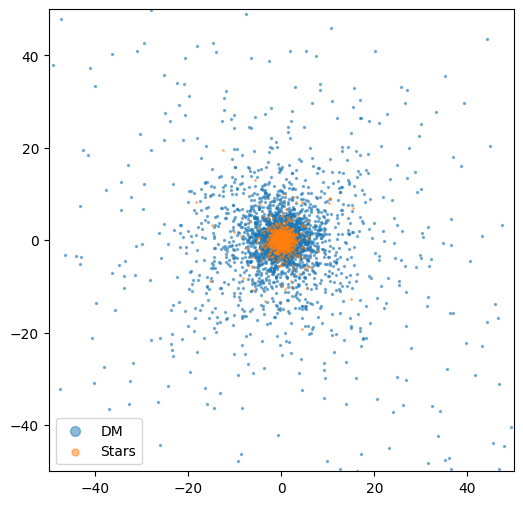

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(sim.dm.x(0), sim.dm.y(0), s=frac, alpha=0.5, label='DM')
plt.scatter(sim.stars.x(0), sim.stars.y(0), s=1, alpha=0.5, label='Stars')

plt.xlim(-50, 50)
plt.ylim(-50, 50)
plt.legend(markerscale=5)

# Run Simulation

In [61]:
sim.run(0.2, dt=0.001, dt_out=0.005, eps={'stars': 0.01, 'dm': 0.1})

  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [00:04<00:00, 43.52it/s]


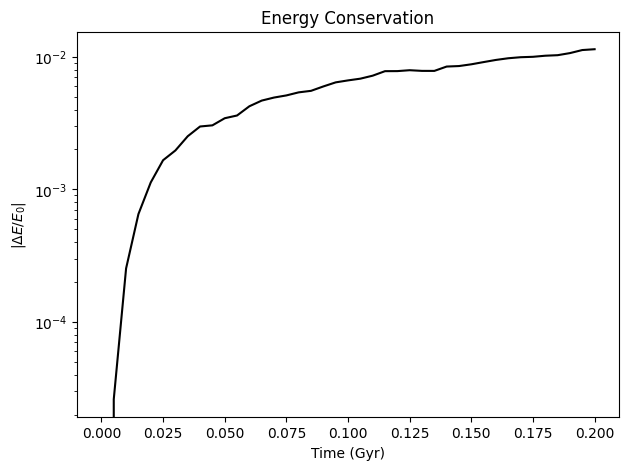

In [62]:
sim.plot_energy_diagnostic()

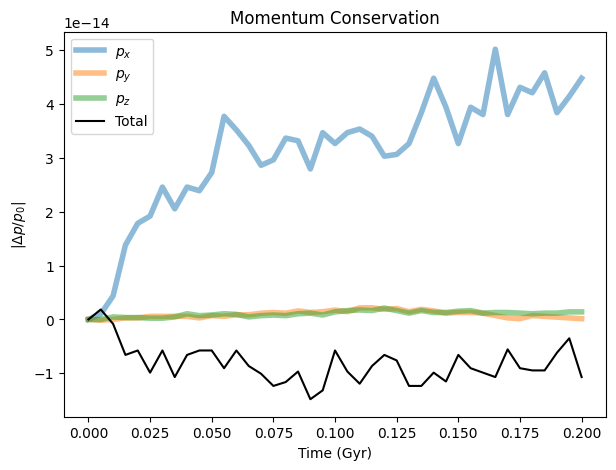

In [63]:
sim.plot_momentum_diagnostic()

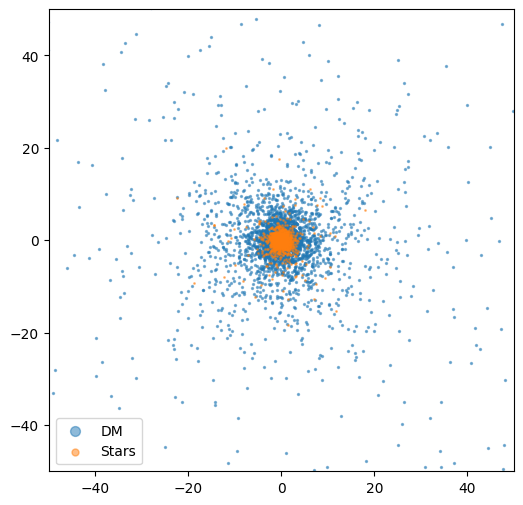

In [69]:
plt.figure(figsize=(6, 6))
plt.scatter(sim.dm.x(-1), sim.dm.y(-1), s=frac, alpha=0.5, label='DM')
plt.scatter(sim.stars.x(-1), sim.stars.y(-1), s=1, alpha=0.5, label='Stars')

plt.xlim(-50, 50)
plt.ylim(-50, 50)
plt.legend(markerscale=5)

In [70]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

n_frames = len(sim.x())//1  # t_end=100, dt_out=10 -> snapshots at 0,10,...,100

fig_anim, ax_anim = plt.subplots(figsize=(6, 6))
dm_sc = ax_anim.scatter(sim.dm.x(0), sim.dm.y(0), s=frac, c='r', alpha=0.5)
st_sc = ax_anim.scatter(sim.stars.x(0), sim.stars.y(0), s=1, c='b', alpha=0.5)
ax_anim.set_xlim(-50, 50)
ax_anim.set_ylim(-50, 50)
ax_anim.set_xlabel('x [kpc]', fontsize=20)
ax_anim.set_ylabel('y [kpc]', fontsize=20)
ax_anim.set_aspect('equal')
title = ax_anim.set_title('t = 0', fontsize=22)
ax_anim.legend(['DM', 'Stars'], markerscale=5, fontsize=12)

def update(i):
    i *= 1
    st_sc.set_offsets(list(zip(sim.stars.x(i), sim.stars.y(i))))
    dm_sc.set_offsets(list(zip(sim.dm.x(i), sim.dm.y(i))))
    title.set_text(f't = {sim.times[i]*1000:.0f} Myr')
    return st_sc, dm_sc, title

anim = FuncAnimation(fig_anim, update, frames=n_frames, interval=100, blit=False)
plt.close(fig_anim)
fig_anim.tight_layout()
anim.save(
    'multicomp_evolution.gif',
    writer='pillow',
    fps=10
)

# Add external potential 

In [71]:
prog_center_pos = np.array([20, 0, 0]) * u.kpc
prog_center_vel = np.array([0, 220, 0]) * u.km/u.s

In [72]:
star_pos_ext, star_vel_ext = galpy_orbit_to_ezfalcon(star_sample)
star_pos_ext += prog_center_pos.value
star_vel_ext += prog_center_vel.value

dm_pos_ext, dm_vel_ext = galpy_orbit_to_ezfalcon(dm_sample)
dm_pos_ext += prog_center_pos.value
dm_vel_ext += prog_center_vel.value

In [73]:
simext = Sim()
simext.add_particles('stars', pos=star_pos_ext, vel=star_vel_ext, mass=np.repeat(mstar_pt, nstar))
simext.add_particles('dm', pos=dm_pos_ext, vel=dm_vel_ext, mass=np.repeat(mdm_pt, ndm))

In [74]:
simext.add_external_pot(hostpot)

In [79]:
simext.run(2, dt=0.0005, dt_out=0.05, eps={'stars': 0.01, 'dm': 0.1})

  0%|          | 0/4000 [00:00<?, ?it/s]

100%|██████████| 4000/4000 [01:31<00:00, 43.72it/s]


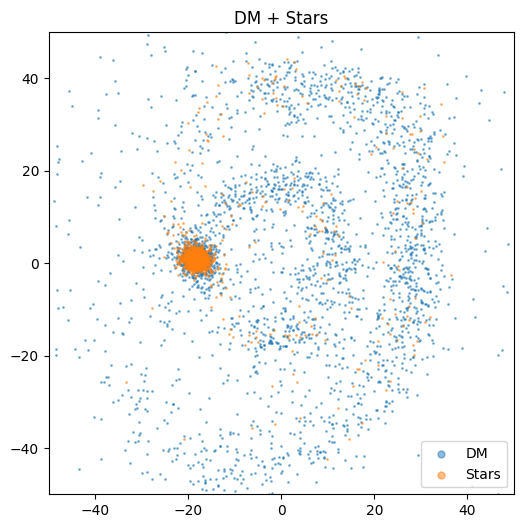

In [80]:
plt.figure(figsize=(6, 6))
plt.scatter(simext.dm.x(-1), simext.dm.y(-1), s=1, alpha=0.5, label='DM')
plt.scatter(simext.stars.x(-1), simext.stars.y(-1), s=1, alpha=0.5, label='Stars')

plt.xlim(-50, 50)
plt.ylim(-50, 50)
plt.title('DM + Stars')
plt.legend(markerscale=5)

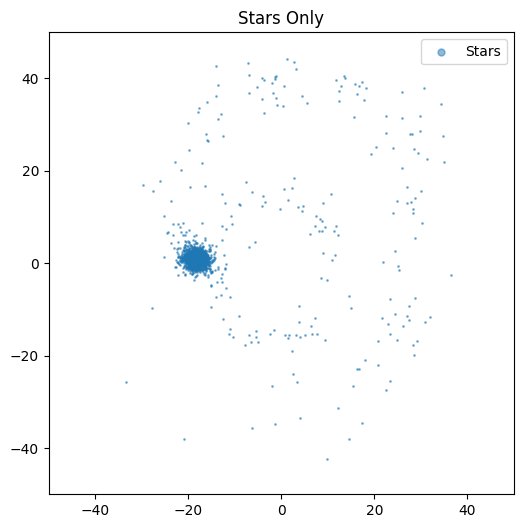

In [81]:
plt.figure(figsize=(6, 6))
#plt.scatter(simext.dm.x(-1), simext.dm.y(-1), s=1, alpha=0.5, label='DM')
plt.scatter(simext.stars.x(-1), simext.stars.y(-1), s=1, alpha=0.5, label='Stars')

plt.xlim(-50, 50)
plt.ylim(-50, 50)
plt.title('Stars Only')
plt.legend(markerscale=5)

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/simulation/simulation.py:1049: UserWarning: Computing external potential on-the-fly for multiple snapshots may be slow.
  warnings.warn("Computing external potential on-the-fly for multiple snapshots may be slow.")



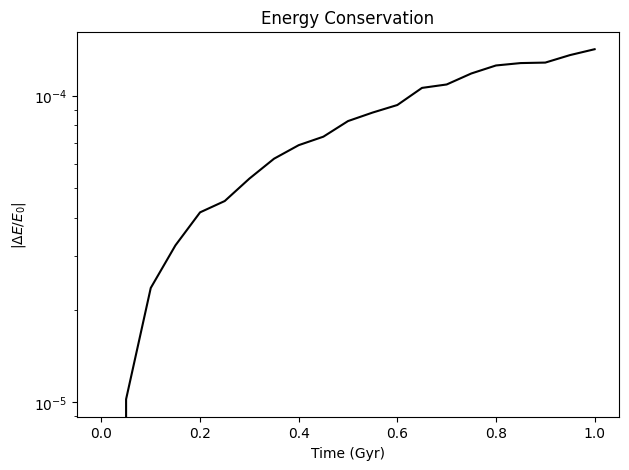

In [78]:
simext.plot_energy_diagnostic()